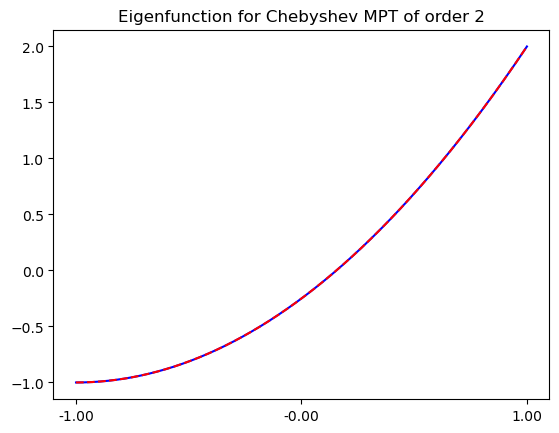

-0.250000000000000


In [1]:
%run ../python/chebyshevMPT.py
from numpy import linspace, mean
from numpy.polynomial import Polynomial
import sympy as sp
import matplotlib.pyplot as plt
from functools import partial


order = 2
chebym = ChebyshevMPT(order)
u = linspace(-1.0+1e-8,1.0-1e-8,num=1000, endpoint=True)

# Proposed eigenfunction as polynomials
p = Polynomial([-1, 6, 3])
d = p.degree()
lambdad = 1/(2**d)

Pf = [chebym.FP(p,u1) for u1 in u]
flam = [lambdad*p(u1) for u1 in u]
fig, ax = plt.subplots()
ax.plot(u,Pf, label='Pf', color='blue')
ax.plot(u, flam, label='$\\lambda f$', color='red', linestyle="--")
ax.set_title(f"Eigenfunction for Chebyshev MPT of order {order}")
ax.set_xticks(chebym.extrema)
extrstr = ["{:.2f}".format(x) for x in chebym.extrema]
ax.set_xticklabels(extrstr)
plt.show()

print(sp.euler(2,0.5))

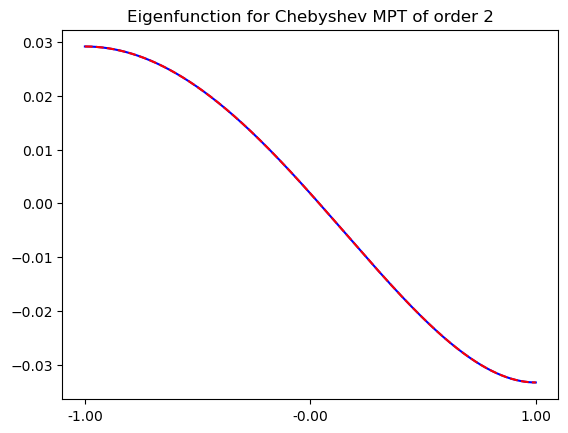

In [3]:
# This chunk implements the spectral decomposition provided
# by Claude 5.0 on September 13, 2026.
#
# Note that there is a sign difference on x in the pB
# function relative to the Claude guidance. 


def pB(x,deg):
    return (sp.bernoulli(2*deg,(1-x)/2) -
              deg*sp.euler(2*deg-1,(1-x)/2))

d = 2
Pf = [chebym.FP(partial(pB, deg=d),u1) for u1 in u]
flam = [(0.25**d)*pB(u1,d) for u1 in u]

fig, ax = plt.subplots()
ax.plot(u,Pf, label='Pf', color='blue')
ax.plot(u, flam, label='$\\lambda f$', color='red', linestyle="--")
ax.set_title(f"Eigenfunction for Chebyshev MPT of order {order}")
ax.set_xticks(chebym.extrema)
extrstr = ["{:.2f}".format(x) for x in chebym.extrema]
ax.set_xticklabels(extrstr)
plt.show()


Expressed in terms of $w=(1+x)/2$, it appears that we can write the EGF for the eigenfunctions as 
$$
\frac{2te^{tw}}{e^{2t}-1}.
$$
This would need to be verified. 


-0.0007281818181818153
-0.0007281818181818182


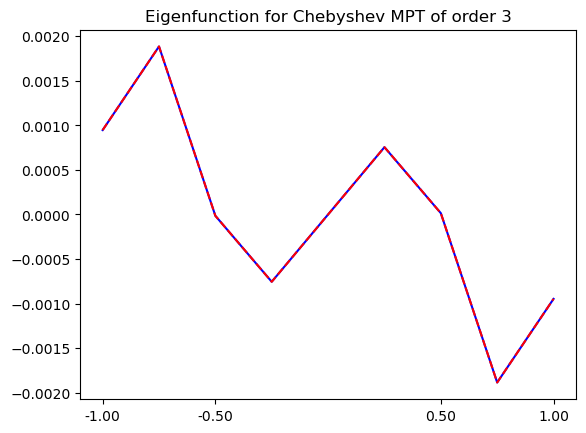

In [3]:
# Case n=3:
order = 3
chebym = ChebyshevMPT(order)

# Proposed eigenfunction as polynomials
eigfunclist = [[1], [0, 1], [-1/3, 0, 1], [0, 0, 0, 1],
               [3/10, 0, -3/2, 0, 1],
               [0, 3/11, 0, -4/3, 0, 1]]
eigvallist = [1, -1/2, -1/8, -1/8, 1/16, 1/64]
d = 5
p = Polynomial(eigfunclist[d])
lambdad = eigvallist[d]

print(chebym.FP(p,0.6))
print(lambdad*p(0.6))

u = linspace(-1.0+1e-6,1.0-1e-6,num=9, endpoint=True)
Pf = [chebym.FP(p,u1) for u1 in u]
flam = [lambdad*p(u1) for u1 in u]

fig, ax = plt.subplots()
ax.plot(u,Pf, label='Pf', color='blue')
ax.plot(u, flam, label='$\\lambda f$', color='red', linestyle="--")
ax.set_title(f"Eigenfunction for Chebyshev MPT of order {order}")
ax.set_xticks(chebym.extrema)
extrstr = ["{:.2f}".format(x) for x in chebym.extrema]
ax.set_xticklabels(extrstr)
plt.show()


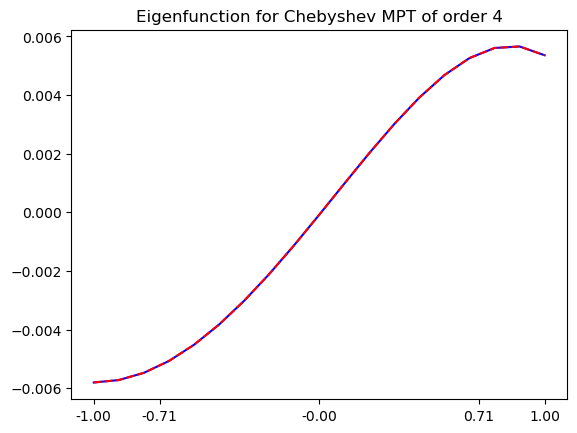

-8.37053571428742e-5


In [15]:
order = 4
chebym = ChebyshevMPT(order)
u = linspace(-1.0+1e-6,1.0-1e-6,num=19, endpoint=True)

# Proposed eigenfunction as polynomials
d = 2
lambdad = 1/(4**d)

def p2(x):
    y = (1-x)/2
    return (sp.bernoulli(2,y) - sp.euler(1,y))
    #return 2 -6*y + 3*y**2

def p4(x):
    y = (1-x)/2
    py = Polynomial([409, 0, -720, -240, 105])
    #return py(y)
    return (sp.bernoulli(4,y) - 2*sp.euler(3,y) + (2/7)*p2(x)) 

Pf = [chebym.FP(p4,u1) for u1 in u]
flam = [(-1/64)*p4(u1) for u1 in u]
fig, ax = plt.subplots()
ax.plot(u,Pf, label='Pf', color='blue')
ax.plot(u, flam, label='$\\lambda f$', color='red', linestyle="--")
ax.set_title(f"Eigenfunction for Chebyshev MPT of order {order}")
ax.set_xticks(chebym.extrema)
extrstr = ["{:.2f}".format(x) for x in chebym.extrema]
ax.set_xticklabels(extrstr)
plt.show()

print(chebym.FP(p4,0))

0.265625


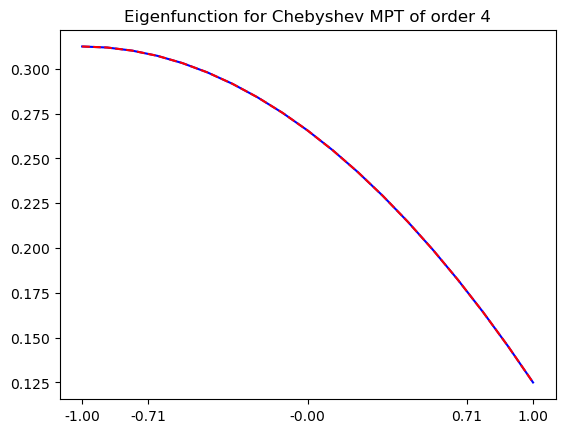

In [34]:

# Proposed eigenfunction as polynomials
p = Polynomial([-2, -6, 3])
d = p.degree()
lambdad = 1/(2**d)

def p3(x):
    y = (1-x)/2
    return y**3

print(chebym.FP(p3,0))

Pf = [chebym.FP(p3,u1) for u1 in u]
flam = [(-1/16)*p((1-u1)/2) for u1 in u]
fig, ax = plt.subplots()
ax.plot(u,Pf, label='Pf', color='blue')
ax.plot(u, flam, label='$\\lambda f$', color='red', linestyle="--")
ax.set_title(f"Eigenfunction for Chebyshev MPT of order {order}")
ax.set_xticks(chebym.extrema)
extrstr = ["{:.2f}".format(x) for x in chebym.extrema]
ax.set_xticklabels(extrstr)
plt.show()

In [16]:
def py(x,deg):
    y = (1-x)/2
    return y**deg

d = 4
print(chebym.FP(partial(py, deg=d),-0.999999))

0.26562499999995315


In [43]:
import numpy as np

def frobenius_perron_m4(f, x_vals):
    results = []
    for x in x_vals:
        alpha = np.arcsin((x + 1) / (2 * np.sqrt(2)))
        s = np.cos(alpha)
        t = np.sin(alpha)
        
        z0 = (s + t) / np.sqrt(2)
        z1 = (s - t) / np.sqrt(2)
        z2 = -z1
        z3 = -z0
        
        dsdt = 1 / (2 * np.sqrt(2) * s)
        dz0_dx = (-t + s) / (np.sqrt(2)) * dsdt
        dz1_dx = (-t - s) / (np.sqrt(2)) * dsdt
        
        w0 = abs(dz0_dx)
        w1 = abs(dz1_dx)
        
        result = w0 * f(z0) + w1 * f(z1) + w1 * f(z2) + w0 * f(z3)
        results.append(result)
    
    return np.array(results)

def B_4(y):
    y2 = y * y
    y3 = y2 * y
    y4 = y3 * y
    return y4 - 2*y3 + y2 - 1/30

def E_3(y):
    y2 = y * y
    y3 = y2 * y
    return y3 - 1.5*y2 + 0.25

def E_1(y):
    return y - 0.5

def B_2(y):
    y2 = y * y
    return y2 - y + 1/6

def f2(x):
    y = (1 - x) / 2
    return 3 * (B_2(y) - E_1(y))

x_test = 0.0
P_f2 = frobenius_perron_m4(f2, np.array([x_test]))[0]
print(f"At x=0: f_2 = {f2(x_test):.6f}, P(f_2) = {P_f2:.6f}")
print(f"Ratio: {P_f2/f2(x_test):.6f}\n")

print("Scanning...")
for alpha in range(10, 151, 5):
    for beta in range(-100, 21, 5):
        def candidate(x):
            y = (1 - x) / 2
            return alpha * B_4(y) + beta * E_3(y)
        
        P_f = frobenius_perron_m4(candidate, np.array([0.0]))[0]
        f_val = candidate(0.0)
        
        if abs(f_val) > 1e-10:
            ratio = P_f / f_val
            if abs(ratio - 1/16) < 0.001:
                print(f"alpha={alpha}, beta={beta}, ratio={ratio:.6f}")

At x=0: f_2 = -0.250000, P(f_2) = 0.031250
Ratio: -0.125000

Scanning...


In [44]:
import numpy as np

def frobenius_perron_m4(f, x_vals):
    results = []
    for x in x_vals:
        alpha = np.arcsin((x + 1) / (2 * np.sqrt(2)))
        s = np.cos(alpha)
        t = np.sin(alpha)
        
        z0 = (s + t) / np.sqrt(2)
        z1 = (s - t) / np.sqrt(2)
        z2 = -z1
        z3 = -z0
        
        dsdt = 1 / (2 * np.sqrt(2) * s)
        dz0_dx = (-t + s) / (np.sqrt(2)) * dsdt
        dz1_dx = (-t - s) / (np.sqrt(2)) * dsdt
        
        w0 = abs(dz0_dx)
        w1 = abs(dz1_dx)
        
        result = w0 * f(z0) + w1 * f(z1) + w1 * f(z2) + w0 * f(z3)
        results.append(result)
    
    return np.array(results)

def B_4(y):
    y2 = y * y
    y3 = y2 * y
    y4 = y3 * y
    return y4 - 2*y3 + y2 - 1/30

def E_3(y):
    y2 = y * y
    y3 = y2 * y
    return y3 - 1.5*y2 + 0.25

# Test a few simple candidates and see what eigenvalue they have
print("Testing simple candidates to find eigenvalue:\n")

test_cases = [
    (15, 0, "15*B_4"),
    (0, 1, "E_3"),
    (1, 0, "B_4"),
    (15, -40, "15*B_4 - 40*E_3"),
    (105, -280, "105*B_4 - 280*E_3")
]

for alpha, beta, name in test_cases:
    def candidate(x):
        y = (1 - x) / 2
        return alpha * B_4(y) + beta * E_3(y)
    
    x_val = 0.0
    P_f = frobenius_perron_m4(candidate, np.array([x_val]))[0]
    f_val = candidate(x_val)
    
    if abs(f_val) > 1e-10:
        ratio = P_f / f_val
        print(f"{name}: f(0)={f_val:.6f}, P(f)(0)={P_f:.6f}, ratio={ratio:.6f}")

# Broad scan
print("\n\nBroad scan for any consistent eigenvalue:")
for alpha in range(-200, 201, 20):
    for beta in range(-200, 201, 20):
        if alpha == 0 and beta == 0:
            continue
            
        def candidate(x):
            y = (1 - x) / 2
            return alpha * B_4(y) + beta * E_3(y)
        
        # Test at two different points
        x1, x2 = 0.0, 0.5
        P_f1 = frobenius_perron_m4(candidate, np.array([x1]))[0]
        f_val1 = candidate(x1)
        P_f2 = frobenius_perron_m4(candidate, np.array([x2]))[0]
        f_val2 = candidate(x2)
        
        if abs(f_val1) > 1e-10 and abs(f_val2) > 1e-10:
            ratio1 = P_f1 / f_val1
            ratio2 = P_f2 / f_val2
            
            # Check if ratios are consistent
            if abs(ratio1 - ratio2) < 0.01:
                print(f"alpha={alpha:4d}, beta={beta:4d}: ratio={ratio1:.6f}")

Testing simple candidates to find eigenvalue:

15*B_4: f(0)=0.437500, P(f)(0)=-0.045898, ratio=-0.104911
B_4: f(0)=0.029167, P(f)(0)=-0.003060, ratio=-0.104911
15*B_4 - 40*E_3: f(0)=0.437500, P(f)(0)=-0.045898, ratio=-0.104911
105*B_4 - 280*E_3: f(0)=3.062500, P(f)(0)=-0.321289, ratio=-0.104911


Broad scan for any consistent eigenvalue:
alpha=-200, beta= 140: ratio=-0.104911
alpha=-180, beta= 120: ratio=-0.104911
alpha=-160, beta= 120: ratio=-0.104911
alpha=-140, beta= 100: ratio=-0.104911
alpha=-120, beta=  80: ratio=-0.104911
alpha= -80, beta=  60: ratio=-0.104911
alpha= -60, beta=  40: ratio=-0.104911
alpha=  60, beta= -40: ratio=-0.104911
alpha=  80, beta= -60: ratio=-0.104911
alpha= 120, beta= -80: ratio=-0.104911
alpha= 140, beta=-100: ratio=-0.104911
alpha= 160, beta=-120: ratio=-0.104911
alpha= 180, beta=-120: ratio=-0.104911
alpha= 200, beta=-140: ratio=-0.104911


In [49]:
import numpy as np

def frobenius_perron_m4(f, x_vals):
    results = []
    for x in x_vals:
        alpha = np.arcsin((x + 1) / (2 * np.sqrt(2)))
        s = np.cos(alpha)
        t = np.sin(alpha)
        
        z0 = (s + t) / np.sqrt(2)
        z1 = (s - t) / np.sqrt(2)
        z2 = -z1
        z3 = -z0
        
        dsdt = 1 / (2 * np.sqrt(2) * s)
        dz0_dx = (-t + s) / (np.sqrt(2)) * dsdt
        dz1_dx = (-t - s) / (np.sqrt(2)) * dsdt
        
        w0 = abs(dz0_dx)
        w1 = abs(dz1_dx)
        
        result = w0 * f(z0) + w1 * f(z1) + w1 * f(z2) + w0 * f(z3)
        results.append(result)
    
    return np.array(results)

def compute_P_on_yk(k, x_samples):
    """Compute P(y^k) at various x values"""
    def yk(x):
        y = (1 - x) / 2
        result = 1.0
        for i in range(k):
            result = result * y
        return result
    
    P_vals = frobenius_perron_m4(yk, x_samples)
    return P_vals

# Sample points
x_samples = np.linspace(-0.9, 0.9, 20)
y_samples = (1 - x_samples) / 2

print("Computing P(y^k) for k=0,1,2,3,4:\n")

for k in range(5):
    P_vals = compute_P_on_yk(k, x_samples)
    
    # Fit polynomial of degree 4
    coeffs = np.polyfit(y_samples, P_vals, 4)
    
    print(f"P(y^{k}) ≈ ", end="")
    terms = []
    for i, c in enumerate(coeffs):
        deg = 4 - i
        if abs(c) > 1e-6:
            if deg == 0:
                terms.append(f"{c:.4f}")
            elif deg == 1:
                terms.append(f"{c:.4f}*y")
            else:
                terms.append(f"{c:.4f}*y^{deg}")
    if terms:
        print(" + ".join(terms))
    else:
        print("0")
    print()

Computing P(y^k) for k=0,1,2,3,4:

P(y^0) ≈ 1.0000

P(y^1) ≈ 0.5000

P(y^2) ≈ -0.1250*y^2 + 0.2500*y + 0.2500

P(y^3) ≈ -0.1875*y^2 + 0.3750*y + 0.1250

P(y^4) ≈ -0.0156*y^4 + 0.0625*y^3 + -0.2813*y^2 + 0.4375*y + 0.0625



In [51]:
import numpy as np

M = np.array([
    [1,     1/2,   1/4,    1/8,    1/16  ],
    [0,     0,     1/4,    3/8,    7/16  ],
    [0,     0,    -1/8,   -3/16,  -9/32  ],
    [0,     0,     0,      0,      1/16  ],
    [0,     0,     0,      0,     -1/64  ]
])

lam = -1/64

# Solve Mv = λv
# Row 4: M[4,4]*e = λ*e
#        -1/64 * e = -1/64 * e  ✓ (e is free)
# Set e = 64 to avoid fractions

e = 64

# Row 3: M[3,4]*e = λ*d
#        (1/16)*64 = (-1/64)*d
#        4 = -d/64
#        d = -256

d = -256

# Row 2: M[2,2]*c + M[2,3]*d + M[2,4]*e = λ*c
#        (-1/8)*c + (-3/16)*(-256) + (-9/32)*64 = (-1/64)*c
#        (-1/8)*c + 48 - 18 = (-1/64)*c
#        (-1/8 + 1/64)*c = -30
#        (-7/64)*c = -30
#        c = 30 * 64/7 = 1920/7

c = 1920/7

# Row 1: M[1,2]*c + M[1,3]*d + M[1,4]*e = λ*b
#        (1/4)*(1920/7) + (3/8)*(-256) + (7/16)*64 = (-1/64)*b
#        480/7 - 96 + 28 = (-1/64)*b
#        (480 - 672 + 196)/7 = -b/64
#        4/7 = -b/64
#        b = -256/7

b = -256/7

# Row 0: M[0,0]*a + M[0,1]*b + M[0,2]*c + M[0,3]*d + M[0,4]*e = λ*a
#        a + (1/2)*(-256/7) + (1/4)*(1920/7) + (1/8)*(-256) + (1/16)*64 = (-1/64)*a
#        a - 128/7 + 480/7 - 32 + 4 = (-1/64)*a
#        a + 352/7 - 28 = (-1/64)*a
#        (1 + 1/64)*a = 28 - 352/7 = (196 - 352)/7 = -156/7
#        (65/64)*a = -156/7
#        a = -156/7 * 64/65 = -9984/455

a = -9984/455

print(f"Eigenfunction coefficients:")
print(f"a = {a:.6f}")
print(f"b = {b:.6f}")
print(f"c = {c:.6f}")
print(f"d = {d}")
print(f"e = {e}")

# Verify
v = np.array([a, b, c, d, e])
Mv = M @ v
lam_v = lam * v

print(f"\nVerification:")
print(f"Mv = {Mv}")
print(f"λv = {lam_v}")
print(f"Difference: {np.linalg.norm(Mv - lam_v)}")

Eigenfunction coefficients:
a = -21.942857
b = -36.571429
c = 274.285714
d = -256
e = 64

Verification:
Mv = [ 0.34285714  0.57142857 -4.28571429  4.         -1.        ]
λv = [ 0.34285714  0.57142857 -4.28571429  4.         -1.        ]
Difference: 2.504777312823609e-15


In [53]:
# From the exact rational coefficients:
a = -9984/455
b = -256/7
c = 1920/7
d = -256
e = 64

# Fitting: f_4 = α*B_4 + β*E_3 + γ*B_2 + δ*E_1 + ε
# B_4(y) = y^4 - 2*y^3 + y^2 - 1/30
# E_3(y) = y^3 - 1.5*y^2 + 0.25
# B_2(y) = y^2 - y + 1/6
# E_1(y) = y - 0.5

# From coefficients:
alpha = e  # = 64
beta = d + 2*alpha  # = -256 + 128 = -128
gamma = c - alpha + 1.5*beta  # = 1920/7 - 64 - 192
delta = b + gamma  # 
epsilon = a + alpha/30 - 0.25*beta - gamma/6 + 0.5*delta

print("Exact rational coefficients:")
print(f"α = {alpha}")
print(f"β = {beta}")

# Calculate gamma
gamma_exact = 1920/7 - 64 - 192
print(f"γ = 1920/7 - 64 - 192 = 1920/7 - 256")
print(f"  = (1920 - 1792)/7 = 128/7 = {128/7:.6f}")
gamma = 128/7

# Calculate delta
delta_exact = -256/7 + 128/7
print(f"δ = -256/7 + 128/7 = -128/7 = {-128/7:.6f}")
delta = -128/7

# Calculate epsilon
eps_val = a + alpha/30 - 0.25*beta - gamma/6 + 0.5*delta
print(f"ε = {eps_val:.6f}")

print(f"\n\nSo the degree-4 eigenfunction is:")
print(f"f_4(y) = 64*B_4(y) - 128*E_3(y) + (128/7)*B_2(y) - (128/7)*E_1(y)")
print(f"      = 64[B_4(y) - 2*E_3(y) + (2/7)*(B_2(y) - E_1(y))]")
print(f"\nNote: B_2 - E_1 is related to the degree-2 eigenfunction!")

Exact rational coefficients:
α = 64
β = -128
γ = 1920/7 - 64 - 192 = 1920/7 - 256
  = (1920 - 1792)/7 = 128/7 = 18.285714
δ = -256/7 + 128/7 = -128/7 = -18.285714
ε = 0.000000


So the degree-4 eigenfunction is:
f_4(y) = 64*B_4(y) - 128*E_3(y) + (128/7)*B_2(y) - (128/7)*E_1(y)
      = 64[B_4(y) - 2*E_3(y) + (2/7)*(B_2(y) - E_1(y))]

Note: B_2 - E_1 is related to the degree-2 eigenfunction!


In [9]:
import numpy as np

def frobenius_perron_m4(f, x_vals):
    results = []
    for x in x_vals:
        alpha = np.arcsin((x + 1) / (2 * np.sqrt(2)))
        s = np.cos(alpha)
        t = np.sin(alpha)
        
        z0 = (s + t) / np.sqrt(2)
        z1 = (s - t) / np.sqrt(2)
        z2 = -z1
        z3 = -z0
        
        dsdt = 1 / (2 * np.sqrt(2) * s)
        dz0_dx = (-t + s) / (np.sqrt(2)) * dsdt
        dz1_dx = (-t - s) / (np.sqrt(2)) * dsdt
        
        w0 = abs(dz0_dx)
        w1 = abs(dz1_dx)
        
        result = w0 * f(z0) + w1 * f(z1) + w1 * f(z2) + w0 * f(z3)
        results.append(result)
    
    return np.array(results)

def B_4(y):
    y2 = y * y
    y3 = y2 * y
    y4 = y3 * y
    return y4 - 2*y3 + y2 - 1/30

def E_3(y):
    y2 = y * y
    y3 = y2 * y
    return y3 - 1.5*y2 + 0.25

def candidate(x):
    y = (1 - x) / 2
    return B_4(y) - 2*E_3(y)

test_points = [0.0, 0.3, 0.6]
for x_val in test_points:
    P_f = frobenius_perron_m4(candidate, np.array([x_val]))[0]
    f_val = candidate(x_val)
    ratio = P_f / f_val if abs(f_val) > 1e-10 else 0
    print(f"x={x_val}: f={f_val:.6f}, P(f)={P_f:.6f}, ratio={ratio:.6f}")

x=0.0: f=0.029167, P(f)=-0.003060, ratio=-0.104911
x=0.3: f=-0.199827, P(f)=0.005909, ratio=-0.029569
x=0.6: f=-0.403733, P(f)=0.015892, ratio=-0.039362


In [10]:
import numpy as np

def frobenius_perron_m4(f, x_vals):
    results = []
    for x in x_vals:
        alpha = np.arcsin((x + 1) / (2 * np.sqrt(2)))
        s = np.cos(alpha)
        t = np.sin(alpha)
        
        z0 = (s + t) / np.sqrt(2)
        z1 = (s - t) / np.sqrt(2)
        z2 = -z1
        z3 = -z0
        
        dsdt = 1 / (2 * np.sqrt(2) * s)
        dz0_dx = (-t + s) / (np.sqrt(2)) * dsdt
        dz1_dx = (-t - s) / (np.sqrt(2)) * dsdt
        
        w0 = abs(dz0_dx)
        w1 = abs(dz1_dx)
        
        result = w0 * f(z0) + w1 * f(z1) + w1 * f(z2) + w0 * f(z3)
        results.append(result)
    
    return np.array(results)

def B_2(y):
    return y*y - y + 1/6

def E_1(y):
    return y - 0.5

def B_4(y):
    y2 = y * y
    y3 = y2 * y
    y4 = y3 * y
    return y4 - 2*y3 + y2 - 1/30

def E_3(y):
    y2 = y * y
    y3 = y2 * y
    return y3 - 1.5*y2 + 0.25

def g_1(x):
    y = (1 - x) / 2
    return B_2(y) - E_1(y)

def g_2(x):
    y = (1 - x) / 2
    return B_4(y) - 2*E_3(y)

# Test different values of a
print("Testing g_2(x) - a*g_1(x) for m=4:\n")

for a in np.linspace(-2, 2, 41):
    def candidate(x):
        return g_2(x) - a * g_1(x)
    
    test_points = [0.0, 0.3, 0.6]
    ratios = []
    
    for x_val in test_points:
        P_f = frobenius_perron_m4(candidate, np.array([x_val]))[0]
        f_val = candidate(x_val)
        
        if abs(f_val) > 1e-10:
            ratio = P_f / f_val
            ratios.append(ratio)
    
    if len(ratios) == 3:
        avg_ratio = sum(ratios) / 3
        consistency = max(ratios) - min(ratios)
        
        if consistency < 0.001:
            print(f"a = {a:.4f}: eigenvalue = {avg_ratio:.6f}, consistency = {consistency:.6f}")

Testing g_2(x) - a*g_1(x) for m=4:



In [11]:
import numpy as np

def frobenius_perron_m4(f, x_vals):
    results = []
    for x in x_vals:
        alpha = np.arcsin((x + 1) / (2 * np.sqrt(2)))
        s = np.cos(alpha)
        t = np.sin(alpha)
        
        z0 = (s + t) / np.sqrt(2)
        z1 = (s - t) / np.sqrt(2)
        z2 = -z1
        z3 = -z0
        
        dsdt = 1 / (2 * np.sqrt(2) * s)
        dz0_dx = (-t + s) / (np.sqrt(2)) * dsdt
        dz1_dx = (-t - s) / (np.sqrt(2)) * dsdt
        
        w0 = abs(dz0_dx)
        w1 = abs(dz1_dx)
        
        result = w0 * f(z0) + w1 * f(z1) + w1 * f(z2) + w0 * f(z3)
        results.append(result)
    
    return np.array(results)

def B_2(y):
    return y*y - y + 1/6

def E_1(y):
    return y - 0.5

def B_4(y):
    y2 = y * y
    y3 = y2 * y
    y4 = y3 * y
    return y4 - 2*y3 + y2 - 1/30

def E_3(y):
    y2 = y * y
    y3 = y2 * y
    return y3 - 1.5*y2 + 0.25

def g_1(x):
    y = (1 - x) / 2
    return B_2(y) - E_1(y)

def g_2(x):
    y = (1 - x) / 2
    return B_4(y) - 2*E_3(y)

print("Testing g_2(x) - a*g_1(x) for m=4:\n")

best_a = None
best_consistency = float('inf')
best_ratio = None

for a in np.linspace(-10, 10, 201):
    def candidate(x):
        return g_2(x) - a * g_1(x)
    
    test_points = [0.0, 0.3, 0.6]
    ratios = []
    
    for x_val in test_points:
        P_f = frobenius_perron_m4(candidate, np.array([x_val]))[0]
        f_val = candidate(x_val)
        
        if abs(f_val) > 1e-10:
            ratio = P_f / f_val
            ratios.append(ratio)
    
    if len(ratios) == 3:
        avg_ratio = sum(ratios) / 3
        consistency = max(ratios) - min(ratios)
        
        if consistency < best_consistency:
            best_consistency = consistency
            best_a = a
            best_ratio = avg_ratio

print(f"Best result:")
print(f"a = {best_a:.6f}")
print(f"eigenvalue = {best_ratio:.6f}")
print(f"consistency = {best_consistency:.6f}")

# Check if eigenvalue is close to -1/64
print(f"\nTarget eigenvalue -1/64 = {-1/64:.6f}")
print(f"Difference from -1/64: {abs(best_ratio + 1/64):.6f}")

Testing g_2(x) - a*g_1(x) for m=4:

Best result:
a = 10.000000
eigenvalue = -0.115629
consistency = 0.016792

Target eigenvalue -1/64 = -0.015625
Difference from -1/64: 0.100004


In [12]:
import numpy as np

def frobenius_perron_m4(f, x_vals):
    results = []
    for x in x_vals:
        alpha = np.arcsin((x + 1) / (2 * np.sqrt(2)))
        s = np.cos(alpha)
        t = np.sin(alpha)
        
        z0 = (s + t) / np.sqrt(2)
        z1 = (s - t) / np.sqrt(2)
        z2 = -z1
        z3 = -z0
        
        dsdt = 1 / (2 * np.sqrt(2) * s)
        dz0_dx = (-t + s) / (np.sqrt(2)) * dsdt
        dz1_dx = (-t - s) / (np.sqrt(2)) * dsdt
        
        w0 = abs(dz0_dx)
        w1 = abs(dz1_dx)
        
        result = w0 * f(z0) + w1 * f(z1) + w1 * f(z2) + w0 * f(z3)
        results.append(result)
    
    return np.array(results)

def g_1(x):
    y = (1 - x) / 2
    y2 = y * y
    B_2 = y2 - y + 1/6
    E_1 = y - 0.5
    return B_2 - E_1

def g_2(x):
    y = (1 - x) / 2
    y2 = y * y
    y3 = y2 * y
    y4 = y3 * y
    B_4 = y4 - 2*y3 + y2 - 1/30
    E_3 = y3 - 1.5*y2 + 0.25
    return B_4 - 2*E_3

# Test g_2 + (2/7)*g_1
a = 2/7
def candidate(x):
    return g_2(x) + a * g_1(x)

test_points = [0.0, 0.3, 0.6]
print(f"Testing g_2(x) + ({a:.6f})*g_1(x) for m=4:\n")

for x_val in test_points:
    P_f = frobenius_perron_m4(candidate, np.array([x_val]))[0]
    f_val = candidate(x_val)
    ratio = P_f / f_val if abs(f_val) > 1e-10 else 0
    print(f"x={x_val}: f={f_val:.6f}, P(f)={P_f:.6f}, ratio={ratio:.6f}")

print(f"\nTarget eigenvalue: -1/64 = {-1/64:.6f}")

Testing g_2(x) + (0.285714)*g_1(x) for m=4:

x=0.0: f=0.005357, P(f)=-0.000084, ratio=-0.015625
x=0.3: f=-0.174351, P(f)=0.002724, ratio=-0.015625
x=0.6: f=-0.316114, P(f)=0.004939, ratio=-0.015625

Target eigenvalue: -1/64 = -0.015625


In [19]:
import numpy as np

def frobenius_perron_m4(f, x_vals):
    results = []
    for x in x_vals:
        alpha = np.arcsin((x + 1) / (2 * np.sqrt(2)))
        s = np.cos(alpha)
        t = np.sin(alpha)
        
        z0 = (s + t) / np.sqrt(2)
        z1 = (s - t) / np.sqrt(2)
        z2 = -z1
        z3 = -z0
        
        dsdt = 1 / (2 * np.sqrt(2) * s)
        dz0_dx = (-t + s) / (np.sqrt(2)) * dsdt
        dz1_dx = (-t - s) / (np.sqrt(2)) * dsdt
        
        w0 = abs(dz0_dx)
        w1 = abs(dz1_dx)
        
        result = w0 * f(z0) + w1 * f(z1) + w1 * f(z2) + w0 * f(z3)
        results.append(result)
    
    return np.array(results)

def compute_P_on_yk(k, x_samples):
    def yk(x):
        y = (1 - x) / 2
        result = 1.0
        for i in range(k):
            result = result * y
        return result
    
    P_vals = frobenius_perron_m4(yk, x_samples)
    return P_vals

# Sample points
x_samples = np.linspace(-0.9, 0.9, 30)
y_samples = (1 - x_samples) / 2

print("Computing P(y^k) for k=0 through 6:\n")

for k in range(7):
    P_vals = compute_P_on_yk(k, x_samples)
    coeffs = np.polyfit(y_samples, P_vals, 6)
    
    print(f"P(y^{k}) ≈ ", end="")
    terms = []
    for i, c in enumerate(coeffs):
        deg = 6 - i
        if abs(c) > 1e-6:
            terms.append(f"{c:.6f}*y^{deg}" if deg > 0 else f"{c:.6f}")
    print(" + ".join(terms) if terms else "0")
    print()

Computing P(y^k) for k=0 through 6:

P(y^0) ≈ 1.000000

P(y^1) ≈ 0.500000

P(y^2) ≈ -0.125000*y^2 + 0.250000*y^1 + 0.250000

P(y^3) ≈ -0.187500*y^2 + 0.375000*y^1 + 0.125000

P(y^4) ≈ -0.015625*y^4 + 0.062500*y^3 + -0.281250*y^2 + 0.437500*y^1 + 0.062500

P(y^5) ≈ -0.039062*y^4 + 0.156250*y^3 + -0.390625*y^2 + 0.468750*y^1 + 0.031250

P(y^6) ≈ 0.001953*y^6 + -0.011719*y^5 + -0.039062*y^4 + 0.234375*y^3 + -0.492187*y^2 + 0.484375*y^1 + 0.015625



In [20]:
import numpy as np

# Build the matrix from the numerical results
# Columns represent P(1), P(y), P(y^2), ..., P(y^6)
M = np.array([
    [1,      1/2,     1/4,      1/8,       1/16,      1/32,      1/64     ],
    [0,      0,       1/4,      3/8,       7/16,      15/32,     31/64    ],
    [0,      0,      -1/8,     -3/16,     -9/32,     -25/64,    -63/128   ],
    [0,      0,       0,        0,         1/16,      5/32,      15/64    ],
    [0,      0,       0,        0,        -1/64,     -5/128,    -5/128    ],
    [0,      0,       0,        0,         0,         0,        -3/256    ],
    [0,      0,       0,        0,         0,         0,         1/512    ]
])

print("Matrix M:")
print(M)
print("\nEigenvalues (diagonal):")
eigenvals = np.diag(M)
print(eigenvals)
print("\nAs fractions: 1, 0, -1/8, 0, -1/64, 0, 1/512")

# Find degree-6 eigenfunction with eigenvalue 1/512
lam = 1/512

print(f"\n\nSolving for eigenfunction with λ = {lam}:")

# Work backwards from row 6
e = [0] * 7

# Row 6: e[6] is free
e[6] = 512  # Choose to avoid fractions

# Row 5: M[5,6]*e[6] = lam*e[5]
# (-3/256)*512 = (1/512)*e[5]
# -6 = e[5]/512
e[5] = -6 * 512
print(f"e[5] = {e[5]}")

# Row 4: M[4,4]*e[4] + M[4,5]*e[5] + M[4,6]*e[6] = lam*e[4]
# (-1/64)*e[4] + (-5/128)*e[5] + (-5/128)*512 = (1/512)*e[4]
# (-1/64 - 1/512)*e[4] = -(-5/128)*e[5] - (-5/128)*512
# (-9/512)*e[4] = (5/128)*e[5] + (5/128)*512
e_4_rhs = (5/128)*e[5] + (5/128)*512
e[4] = e_4_rhs / (-9/512)
print(f"e[4] = {e[4]}")

# Row 3: M[3,3]*e[3] + M[3,4]*e[4] + M[3,5]*e[5] + M[3,6]*e[6] = lam*e[3]
# 0 + (1/16)*e[4] + (5/32)*e[5] + (15/64)*512 = (1/512)*e[3]
e_3_rhs = (1/16)*e[4] + (5/32)*e[5] + (15/64)*512
e[3] = e_3_rhs / (1/512)
print(f"e[3] = {e[3]}")

# Continue similarly for e[2], e[1], e[0]
# Row 2:
e_2_val = M[2,2]*0 + M[2,3]*e[3] + M[2,4]*e[4] + M[2,5]*e[5] + M[2,6]*e[6]
e[2] = e_2_val / (lam - M[2,2])
print(f"e[2] = {e[2]}")

# Row 1:
e_1_val = M[1,2]*e[2] + M[1,3]*e[3] + M[1,4]*e[4] + M[1,5]*e[5] + M[1,6]*e[6]
e[1] = e_1_val / (lam - M[1,1])
print(f"e[1] = {e[1]}")

# Row 0:
e_0_val = M[0,1]*e[1] + M[0,2]*e[2] + M[0,3]*e[3] + M[0,4]*e[4] + M[0,5]*e[5] + M[0,6]*e[6]
e[0] = e_0_val / (lam - M[0,0])
print(f"e[0] = {e[0]}")

print(f"\n\nEigenfunction coefficients: {e}")

# Verify
v = np.array(e)
Mv = M @ v
lam_v = lam * v
print(f"\nVerification ||Mv - λv|| = {np.linalg.norm(Mv - lam_v)}")

Matrix M:
[[ 1.          0.5         0.25        0.125       0.0625      0.03125
   0.015625  ]
 [ 0.          0.          0.25        0.375       0.4375      0.46875
   0.484375  ]
 [ 0.          0.         -0.125      -0.1875     -0.28125    -0.390625
  -0.4921875 ]
 [ 0.          0.          0.          0.          0.0625      0.15625
   0.234375  ]
 [ 0.          0.          0.          0.         -0.015625   -0.0390625
  -0.0390625 ]
 [ 0.          0.          0.          0.          0.          0.
  -0.01171875]
 [ 0.          0.          0.          0.          0.          0.
   0.00195312]]

Eigenvalues (diagonal):
[ 1.          0.         -0.125       0.         -0.015625    0.
  0.00195312]

As fractions: 1, 0, -1/8, 0, -1/64, 0, 1/512


Solving for eigenfunction with λ = 0.001953125:
e[5] = -3072
e[4] = 5688.888888888889
e[3] = -2275.555555555562
e[2] = -1774.9333333333238
e[1] = -91.02222222229466
e[0] = 507.1238095238443


Eigenfunction coefficients: [np.float64(507.123809

In [21]:
import numpy as np

# Eigenfunction coefficients: [const, y, y^2, y^3, y^4, y^5, y^6]
f_6_coeffs = np.array([507.124, -91.022, -1774.933, -2275.556, 5688.889, -3072, 512])

# Compute g_k polynomial coefficients
# g_1(y) = B_2(y) - E_1(y)
# B_2 = y^2 - y + 1/6
# E_1 = y - 1/2
# g_1 = y^2 - 2y + 2/3
g_1_coeffs = np.array([2/3, -2, 1, 0, 0, 0, 0])

# g_2(y) = B_4(y) - 2*E_3(y)
# B_4 = y^4 - 2y^3 + y^2 - 1/30
# E_3 = y^3 - 3y^2/2 + 1/4
# g_2 = y^4 - 4y^3 + 4y^2 - 8/15
g_2_coeffs = np.array([-8/15, 0, 4, -4, 1, 0, 0])

# g_3(y) = B_6(y) - 3*E_5(y)
# B_6 = 1/42 - y^2/2 + 5y^4/2 - 3y^5 + y^6
# E_5 = -1/2 + 5y^2/2 - 5y^4/2 + y^5
# g_3 = (1/42 + 3/2) + (-1/2 - 15/2)y^2 + (5/2 + 15/2)y^4 + (-3 - 3)y^5 + y^6
#     = 32/21 - 8y^2 + 10y^4 - 6y^5 + y^6
g_3_coeffs = np.array([32/21, 0, -8, 0, 10, -6, 1])

print("g_1 coefficients:", g_1_coeffs)
print("g_2 coefficients:", g_2_coeffs)
print("g_3 coefficients:", g_3_coeffs)

# Solve for a, b, c in: f_6 = a*g_3 + b*g_2 + c*g_1
# This is a linear system

# Set up matrix with g_k as columns
G = np.column_stack([g_3_coeffs, g_2_coeffs, g_1_coeffs])

# Solve G @ [a, b, c]^T = f_6_coeffs
abc = np.linalg.lstsq(G, f_6_coeffs, rcond=None)[0]

a, b, c = abc
print(f"\nFitting f_6 = a*g_3 + b*g_2 + c*g_1:")
print(f"a = {a:.6f}")
print(f"b = {b:.6f}")
print(f"c = {c:.6f}")

# Try to identify as simple fractions
from fractions import Fraction
print(f"\nAs fractions:")
print(f"a ≈ {Fraction(a).limit_denominator(1000)}")
print(f"b ≈ {Fraction(b).limit_denominator(1000)}")
print(f"c ≈ {Fraction(c).limit_denominator(1000)}")

# Verify the fit
f_6_fit = a * g_3_coeffs + b * g_2_coeffs + c * g_1_coeffs
error = np.linalg.norm(f_6_coeffs - f_6_fit)
print(f"\nFit error: {error:.9f}")

g_1 coefficients: [ 0.66666667 -2.          1.          0.          0.          0.
  0.        ]
g_2 coefficients: [-0.53333333  0.          4.         -4.          1.          0.
  0.        ]
g_3 coefficients: [ 1.52380952  0.         -8.          0.         10.         -6.
  1.        ]

Fitting f_6 = a*g_3 + b*g_2 + c*g_1:
a = 512.000003
b = 568.888992
c = 45.511049

As fractions:
a ≈ 512
b ≈ 568889/1000
c ≈ 16475/362

Fit error: 0.000301953


In [22]:
import numpy as np
from fractions import Fraction

a = 512
b = 568.888992
c = 45.511049

# Try more careful fraction approximations
print("Trying to identify b:")
for denom in [7, 9, 11, 13, 15, 21, 27, 33, 63]:
    frac = Fraction(b).limit_denominator(denom)
    if abs(float(frac) - b) < 0.001:
        print(f"  {frac} = {float(frac):.6f}")

print("\nTrying to identify c:")
for denom in [7, 9, 11, 13, 15, 21, 27, 33, 63]:
    frac = Fraction(c).limit_denominator(denom)
    if abs(float(frac) - c) < 0.001:
        print(f"  {frac} = {float(frac):.6f}")

# Based on pattern from degree 4 (which had 2/7), try denominators related to 9
print("\nChecking specific values:")
print(f"5120/9 = {5120/9:.6f} (for b)")
print(f"410/9 = {410/9:.6f} (for c)")

# Verify with these values
b_exact = 5120/9
c_exact = 410/9

print(f"\nTesting f_6 = 512*g_3 + (5120/9)*g_2 + (410/9)*g_1:")

# Define g functions
def g_1(x):
    y = (1 - x) / 2
    return y2 - 2*y + 2/3

def g_2(x):
    y = (1 - x) / 2
    return y**4 - 4*y**3 + 4*y2 - 8/15

def g_3(x):
    y = (1 - x) / 2
    return 1 + y**6 - 6*y**5 + 10*y**4 - 8*y**2 + 32/21

def candidate(x):
    return 512 * g_3(x) + b_exact * g_2(x) + c_exact * g_1(x)

# We'd need to test this with the Frobenius-Perron operator
print(f"\nProposed form: f_6 = 512*g_3 + (5120/9)*g_2 + (410/9)*g_1")
print(f"Factored: f_6 = 512[g_3 + (10/9)*g_2 + (410/4608)*g_1]")
print(f"         = 512[g_3 + (10/9)*g_2 + (205/2304)*g_1]")

Trying to identify b:
  5120/9 = 568.888889
  5120/9 = 568.888889
  5120/9 = 568.888889
  5120/9 = 568.888889
  5120/9 = 568.888889
  5120/9 = 568.888889
  5120/9 = 568.888889
  5120/9 = 568.888889

Trying to identify c:
  2048/45 = 45.511111

Checking specific values:
5120/9 = 568.888889 (for b)
410/9 = 45.555556 (for c)

Testing f_6 = 512*g_3 + (5120/9)*g_2 + (410/9)*g_1:

Proposed form: f_6 = 512*g_3 + (5120/9)*g_2 + (410/9)*g_1
Factored: f_6 = 512[g_3 + (10/9)*g_2 + (410/4608)*g_1]
         = 512[g_3 + (10/9)*g_2 + (205/2304)*g_1]


In [24]:
import numpy as np

def frobenius_perron_m4(f, x_vals):
    results = []
    for x in x_vals:
        alpha = np.arcsin((x + 1) / (2 * np.sqrt(2)))
        s = np.cos(alpha)
        t = np.sin(alpha)
        
        z0 = (s + t) / np.sqrt(2)
        z1 = (s - t) / np.sqrt(2)
        z2 = -z1
        z3 = -z0
        
        dsdt = 1 / (2 * np.sqrt(2) * s)
        dz0_dx = (-t + s) / (np.sqrt(2)) * dsdt
        dz1_dx = (-t - s) / (np.sqrt(2)) * dsdt
        
        w0 = abs(dz0_dx)
        w1 = abs(dz1_dx)
        
        result = w0 * f(z0) + w1 * f(z1) + w1 * f(z2) + w0 * f(z3)
        results.append(result)
    
    return np.array(results)

def g_1(x):
    y = (1 - x) / 2
    y2 = y * y
    return y2 - 2*y + 2/3

def g_2(x):
    y = (1 - x) / 2
    y2 = y * y
    y3 = y2 * y
    y4 = y3 * y
    return y4 - 4*y3 + 4*y2 - 8/15

def g_3(x):
    y = (1 - x) / 2
    y2 = y * y
    y4 = y2 * y2
    y5 = y4 * y
    y6 = y5 * y
    return y6 - 6*y5 + 10*y4 - 8*y2 + 32/21

def f_6(x):
    return 512 * g_3(x) + (5120/9) * g_2(x) + (2048/45) * g_1(x)

test_points = [0.0, 0.3, 0.6]
print(f"Testing f_6 = 512*g_3 + (5120/9)*g_2 + (2048/45)*g_1:\n")

for x_val in test_points:
    P_f = frobenius_perron_m4(f_6, np.array([x_val]))[0]
    f_val = f_6(x_val)
    ratio = P_f / f_val if abs(f_val) > 1e-10 else 0
    print(f"x={x_val}: f={f_val:.6f}, P(f)={P_f:.6f}, ratio={ratio:.9f}")

print(f"\nTarget eigenvalue: 1/512 = {1/512:.9f}")

print("\n\nFactored form:")
print(f"f_6 = 512[g_3 + (10/9)*g_2 + (4/45)*g_1]")

Testing f_6 = 512*g_3 + (5120/9)*g_2 + (2048/45)*g_1:

x=0.0: f=0.990476, P(f)=0.001935, ratio=0.001953125
x=0.3: f=230.447615, P(f)=0.450093, ratio=0.001953125
x=0.6: f=407.869538, P(f)=0.796620, ratio=0.001953125

Target eigenvalue: 1/512 = 0.001953125


Factored form:
f_6 = 512[g_3 + (10/9)*g_2 + (4/45)*g_1]


In [25]:
import numpy as np

def frobenius_perron_m4(f, x_vals):
    results = []
    for x in x_vals:
        alpha = np.arcsin((x + 1) / (2 * np.sqrt(2)))
        s = np.cos(alpha)
        t = np.sin(alpha)
        
        z0 = (s + t) / np.sqrt(2)
        z1 = (s - t) / np.sqrt(2)
        z2 = -z1
        z3 = -z0
        
        dsdt = 1 / (2 * np.sqrt(2) * s)
        dz0_dx = (-t + s) / (np.sqrt(2)) * dsdt
        dz1_dx = (-t - s) / (np.sqrt(2)) * dsdt
        
        w0 = abs(dz0_dx)
        w1 = abs(dz1_dx)
        
        result = w0 * f(z0) + w1 * f(z1) + w1 * f(z2) + w0 * f(z3)
        results.append(result)
    
    return np.array(results)

def compute_P_on_yk(k, x_samples):
    def yk(x):
        y = (1 - x) / 2
        result = 1.0
        for i in range(k):
            result = result * y
        return result
    
    P_vals = frobenius_perron_m4(yk, x_samples)
    return P_vals

# Sample points
x_samples = np.linspace(-0.9, 0.9, 40)
y_samples = (1 - x_samples) / 2

print("Computing P(y^k) for k=7 and 8:\n")

for k in [7, 8]:
    P_vals = compute_P_on_yk(k, x_samples)
    coeffs = np.polyfit(y_samples, P_vals, 8)
    
    print(f"P(y^{k}) ≈ ", end="")
    terms = []
    for i, c in enumerate(coeffs):
        deg = 8 - i
        if abs(c) > 1e-6:
            terms.append(f"{c:.9f}*y^{deg}" if deg > 0 else f"{c:.9f}")
    print(" + ".join(terms) if terms else "0")
    print()

print("\nNow I'll build the 9x9 matrix and solve for the degree-8 eigenfunction...")

Computing P(y^k) for k=7 and 8:

P(y^7) ≈ 0.006835938*y^6 + -0.041015625*y^5 + 0.273437500*y^3 + -0.574218750*y^2 + 0.492187500*y^1 + 0.007812500

P(y^8) ≈ 0.000244141*y^8 + -0.001953125*y^7 + 0.020507813*y^6 + -0.095703125*y^5 + 0.083007813*y^4 + 0.269531250*y^3 + -0.634765625*y^2 + 0.496093750*y^1 + 0.003906250


Now I'll build the 9x9 matrix and solve for the degree-8 eigenfunction...


In [30]:
import numpy as np
from fractions import Fraction

# Scale the eigenfunction by dividing by 4096
f_8_coeffs = np.array([-12482204.391, 46943530.156, -65922330.986, 43867781.908, 
                        71774.523, -32768.0, 81920.0, -32768.0, 4096.0])

f_8_scaled = f_8_coeffs / 4096

print("Scaled eigenfunction coefficients (divided by 4096):")
for i, c in enumerate(f_8_scaled):
    frac = Fraction(c).limit_denominator(10000)
    print(f"  y^{i}: {c:.6f} ≈ {frac}")

# Let's also look at ratios between coefficients
print("\n\nRatios to e[8] = 4096:")
for i, c in enumerate(f_8_coeffs):
    if i < 8:
        ratio = c / 4096
        frac = Fraction(ratio).limit_denominator(10000)
        print(f"  e[{i}]/e[8] = {ratio:.6f} ≈ {frac}")

# Compare with previous patterns
print("\n\nPrevious patterns:")
print("Degree 4: coefficients scaled by 1")
print("  g_2 + (2/7)*g_1")
print("\nDegree 6: coefficients scaled by 512")  
print("  g_3 + (10/9)*g_2 + (4/45)*g_1")
print("  where 10/9 ≈ 1.111, 4/45 ≈ 0.089")

print("\n\nMaybe degree 8 doesn't follow g_4 + ... pattern?")
print("Perhaps we need to compute P on the actual g_k functions numerically?")

Scaled eigenfunction coefficients (divided by 4096):
  y^0: -3047.413181 ≈ -25939581/8512
  y^1: 11460.822792 ≈ 20113744/1755
  y^2: -16094.319088 ≈ -5649106/351
  y^3: 10709.907692 ≈ 696144/65
  y^4: 17.523077 ≈ 1139/65
  y^5: -8.000000 ≈ -8
  y^6: 20.000000 ≈ 20
  y^7: -8.000000 ≈ -8
  y^8: 1.000000 ≈ 1


Ratios to e[8] = 4096:
  e[0]/e[8] = -3047.413181 ≈ -25939581/8512
  e[1]/e[8] = 11460.822792 ≈ 20113744/1755
  e[2]/e[8] = -16094.319088 ≈ -5649106/351
  e[3]/e[8] = 10709.907692 ≈ 696144/65
  e[4]/e[8] = 17.523077 ≈ 1139/65
  e[5]/e[8] = -8.000000 ≈ -8
  e[6]/e[8] = 20.000000 ≈ 20
  e[7]/e[8] = -8.000000 ≈ -8


Previous patterns:
Degree 4: coefficients scaled by 1
  g_2 + (2/7)*g_1

Degree 6: coefficients scaled by 512
  g_3 + (10/9)*g_2 + (4/45)*g_1
  where 10/9 ≈ 1.111, 4/45 ≈ 0.089


Maybe degree 8 doesn't follow g_4 + ... pattern?
Perhaps we need to compute P on the actual g_k functions numerically?


In [32]:
import numpy as np
import sympy as sp

def frobenius_perron_m4(f, x_vals):
    results = []
    for x in x_vals:
        alpha = np.arcsin((x + 1) / (2 * np.sqrt(2)))
        s = np.cos(alpha)
        t = np.sin(alpha)
        
        z0 = (s + t) / np.sqrt(2)
        z1 = (s - t) / np.sqrt(2)
        z2 = -z1
        z3 = -z0
        
        dsdt = 1 / (2 * np.sqrt(2) * s)
        dz0_dx = (-t + s) / (np.sqrt(2)) * dsdt
        dz1_dx = (-t - s) / (np.sqrt(2)) * dsdt
        
        w0 = abs(dz0_dx)
        w1 = abs(dz1_dx)
        
        result = w0 * f(z0) + w1 * f(z1) + w1 * f(z2) + w0 * f(z3)
        results.append(result)
    
    return np.array(results)

def g_func(k):
    def g_k(x):
        y = (1 - x) / 2
        y_sym = sp.Symbol('y_val')
        g_expr = sp.bernoulli(2*k, y_sym) - k*sp.euler(2*k-1, y_sym)
        return float(g_expr.subs(y_sym, y))
    return g_k

g1 = g_func(1)
g2 = g_func(2)
g3 = g_func(3)
g4 = g_func(4)

target_eigenvalue = 1/4096

print("Searching for a, b, c in: g_4 + a*g_3 + b*g_2 + c*g_1\n")

best_consistency = float('inf')
best_result = None

for a in np.linspace(0, 5, 26):
    for b in np.linspace(0, 5, 26):
        for c in np.linspace(0, 5, 26):
            def candidate(x):
                return g4(x) + a*g3(x) + b*g2(x) + c*g1(x)
            
            test_points = [0.0, 0.3, 0.6]
            ratios = []
            
            for x_val in test_points:
                P_f = frobenius_perron_m4(candidate, np.array([x_val]))[0]
                f_val = candidate(x_val)
                
                if abs(f_val) > 1e-10:
                    ratio = P_f / f_val
                    ratios.append(ratio)
            
            if len(ratios) == 3:
                consistency = max(ratios) - min(ratios)
                
                if consistency < best_consistency:
                    best_consistency = consistency
                    best_result = (a, b, c, np.mean(ratios), consistency)

if best_result:
    a, b, c, eigenval, consistency = best_result
    print(f"Best match found:")
    print(f"  a = {a:.4f}")
    print(f"  b = {b:.4f}")
    print(f"  c = {c:.4f}")
    print(f"  eigenvalue = {eigenval:.9f}")
    print(f"  consistency = {consistency:.9f}")
    print(f"\nTarget: {target_eigenvalue:.9f}")

Searching for a, b, c in: g_4 + a*g_3 + b*g_2 + c*g_1

Best match found:
  a = 4.0000
  b = 4.8000
  c = 0.8000
  eigenvalue = -0.003571693
  consistency = 0.000118750

Target: 0.000244141


In [34]:
import numpy as np
import sympy as sp
from fractions import Fraction

def frobenius_perron_m4(f, x_vals):
    results = []
    for x in x_vals:
        alpha = np.arcsin((x + 1) / (2 * np.sqrt(2)))
        s = np.cos(alpha)
        t = np.sin(alpha)
        
        z0 = (s + t) / np.sqrt(2)
        z1 = (s - t) / np.sqrt(2)
        z2 = -z1
        z3 = -z0
        
        dsdt = 1 / (2 * np.sqrt(2) * s)
        dz0_dx = (-t + s) / (np.sqrt(2)) * dsdt
        dz1_dx = (-t - s) / (np.sqrt(2)) * dsdt
        
        w0 = abs(dz0_dx)
        w1 = abs(dz1_dx)
        
        result = w0 * f(z0) + w1 * f(z1) + w1 * f(z2) + w0 * f(z3)
        results.append(result)
    
    return np.array(results)

def g_func(k):
    def g_k(x):
        y = (1 - x) / 2
        y_sym = sp.Symbol('y_val')
        g_expr = sp.bernoulli(2*k, y_sym) - k*sp.euler(2*k-1, y_sym)
        return float(g_expr.subs(y_sym, y))
    return g_k

g1 = g_func(1)
g2 = g_func(2)
g3 = g_func(3)
g4 = g_func(4)

# Define the actual eigenfunctions we found
def f2(x):  # Degree 2, eigenvalue -1/8
    return g1(x)

def f4(x):  # Degree 4, eigenvalue -1/64
    return g2(x) + (2/7)*g1(x)

def f6(x):  # Degree 6, eigenvalue 1/512
    return g3(x) + (10/9)*g2(x) + (4/45)*g1(x)

# Try: f_8 = a*g4 + b*f6 + c*f4 + d*f2
print("Trying f_8 = a*g4 + b*f6 + c*f4 + d*f2 (using actual eigenfunctions)\n")

target = 1/4096
best_result = None
best_error = float('inf')

for a in np.linspace(0, 2, 21):
    for b in np.linspace(-5, 5, 21):
        for c in np.linspace(-5, 5, 21):
            for d in np.linspace(-5, 5, 21):
                def candidate(x):
                    return a*g4(x) + b*f6(x) + c*f4(x) + d*f2(x)
                
                test_points = [0.0, 0.3, 0.6]
                ratios = []
                
                for x_val in test_points:
                    P_f = frobenius_perron_m4(candidate, np.array([x_val]))[0]
                    f_val = candidate(x_val)
                    
                    if abs(f_val) > 1e-10:
                        ratios.append(P_f / f_val)
                
                if len(ratios) == 3:
                    consistency = max(ratios) - min(ratios)
                    avg_ratio = np.mean(ratios)
                    error = abs(avg_ratio - target)
                    
                    if consistency < 0.0001 and error < best_error:
                        best_error = error
                        best_result = (a, b, c, d, avg_ratio, consistency)

if best_result:
    a, b, c, d, eigenval, consistency = best_result
    print(f"Best match:")
    print(f"  a = {a:.4f}")
    print(f"  b = {b:.4f}")
    print(f"  c = {c:.4f}")
    print(f"  d = {d:.4f}")
    print(f"  eigenvalue = {eigenval:.9f}")
    print(f"  consistency = {consistency:.9f}")
    print(f"\nTarget: {target:.9f}")
    
    # Try to identify as fractions
    for val, name in zip([a,b,c,d], ['a','b','c','d']):
        frac = Fraction(val).limit_denominator(100)
        print(f"  {name} ≈ {frac}")
else:
    print("No match found")

Trying f_8 = a*g4 + b*f6 + c*f4 + d*f2 (using actual eigenfunctions)

Best match:
  a = 1.5000
  b = -4.0000
  c = -2.5000
  d = 0.5000
  eigenvalue = 0.000802968
  consistency = 0.000078013

Target: 0.000244141
  a ≈ 3/2
  b ≈ -4
  c ≈ -5/2
  d ≈ 1/2
